In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("/content/Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [6]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


First, let's examine the value counts for the categorical columns with missing values to determine the most appropriate imputation strategy (e.g., mode).

In [7]:
print('Value counts for Weather:')
display(df['Weather'].value_counts(dropna=False))

print('\nValue counts for Traffic_Level:')
display(df['Traffic_Level'].value_counts(dropna=False))

print('\nValue counts for Time_of_Day:')
display(df['Time_of_Day'].value_counts(dropna=False))

Value counts for Weather:


,count
Weather,
Clear,470
Rainy,204
Foggy,103
Snowy,97
Windy,96
NaN,30



Value counts for Traffic_Level:


,count
Traffic_Level,
Medium,390
Low,383
High,197
NaN,30



Value counts for Time_of_Day:


,count
Time_of_Day,
Morning,308
Evening,293
Afternoon,284
Night,85
NaN,30


Now, I will fill the null values. For categorical columns ('Weather', 'Traffic_Level', 'Time_of_Day'), I will use the mode (most frequent value). For the numerical column ('Courier_Experience_yrs'), I will use the median.

In [8]:
# Fill nulls in categorical columns with the mode
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)

# Fill nulls in 'Courier_Experience_yrs' with the median
median_experience = df['Courier_Experience_yrs'].median()
df['Courier_Experience_yrs'].fillna(median_experience, inplace=True)

Let's re-check the null values to confirm that all missing entries have been filled.

In [9]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [10]:
df.drop('Order_ID' , axis = 1 , inplace = True)

## Exploratory Data Analysis (EDA)

Let's start by understanding the distribution of our target variable, `Delivery_Time_min`.

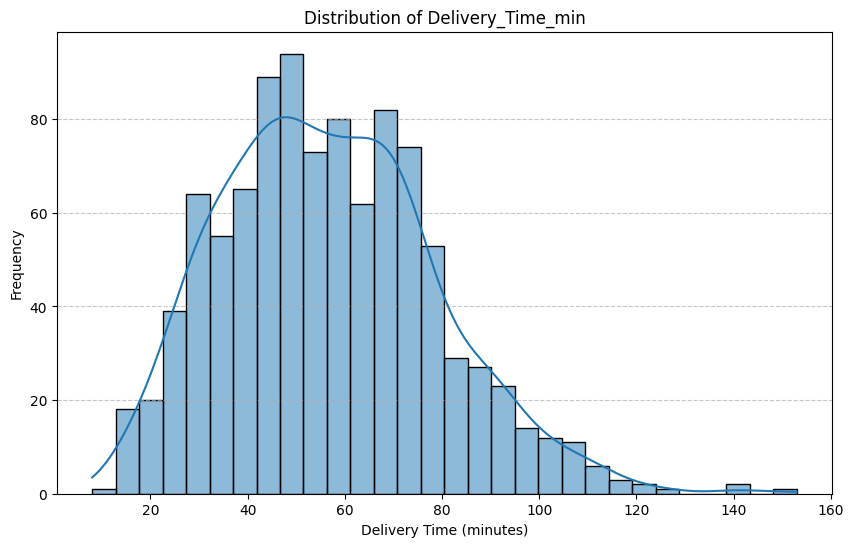

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title('Distribution of Delivery_Time_min')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Next, let's look at the overall descriptive statistics of the dataset.

In [12]:
display(df.describe())

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.592000,56.732000
std,5.696656,7.204553,2.871198,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


Now, let's analyze the relationship between categorical features and the `Delivery_Time_min`.

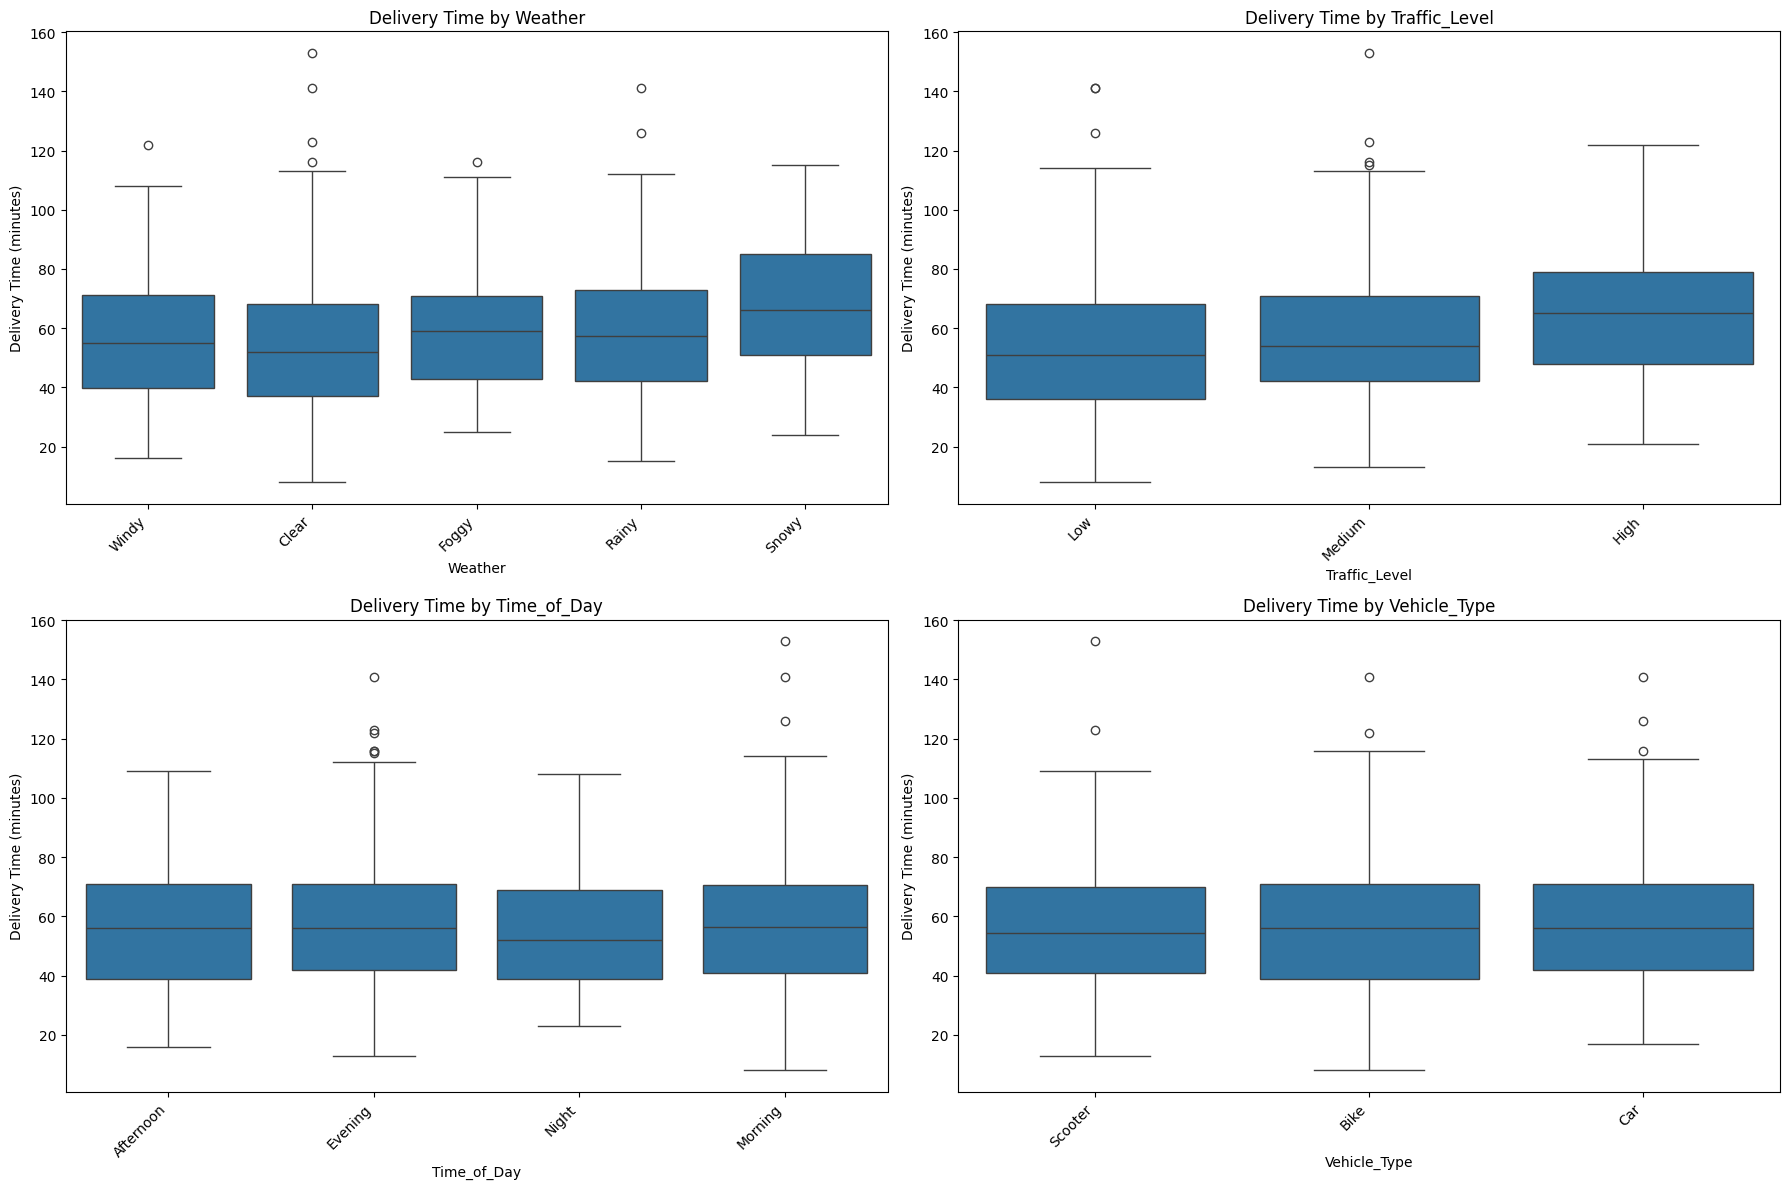

In [13]:
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=col, y='Delivery_Time_min', data=df)
    plt.title(f'Delivery Time by {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (minutes)')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Finally, let's check the correlations between numerical features and the target variable.

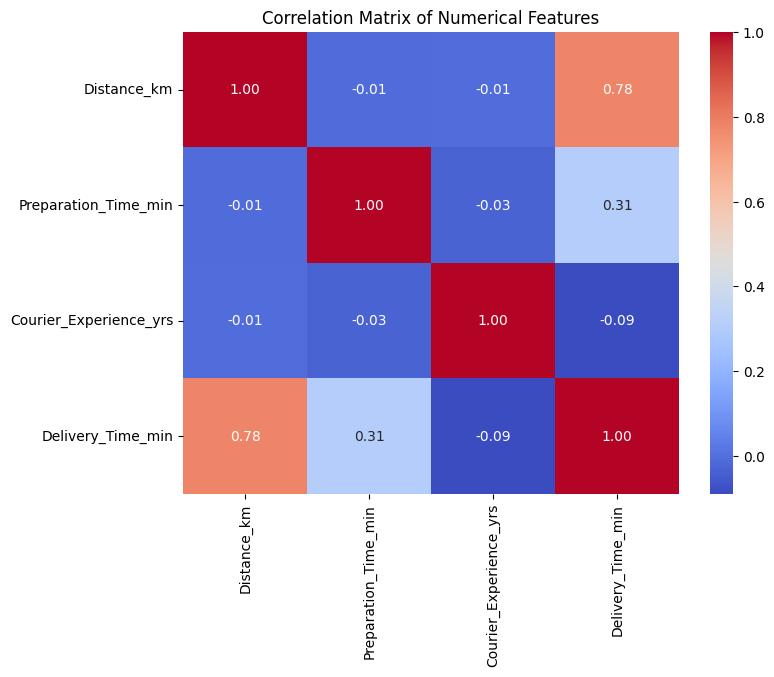

In [14]:
numerical_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Statistical Testing for Feature Selection

To identify the 'best features' that influence `Delivery_Time_min`, we will perform statistical tests. For categorical features, ANOVA is appropriate, and for numerical features, we can use linear regression to assess significance.

### ANOVA for Categorical Features

We will perform a one-way ANOVA test for each categorical variable against `Delivery_Time_min` to see if the means of delivery time are significantly different across the categories. A low p-value (typically < 0.05) indicates a significant difference.

In [15]:
from scipy.stats import f_oneway

categorical_features = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

print('ANOVA Test Results for Categorical Features (vs. Delivery_Time_min):\n')

for col in categorical_features:
    groups = df.groupby(col)['Delivery_Time_min'].apply(list)
    f_statistic, p_value = f_oneway(*groups)
    print(f'Feature: {col}')
    print(f'  F-statistic: {f_statistic:.2f}')
    print(f'  P-value: {p_value:.3f}')
    if p_value < 0.05:
        print(f'  Conclusion: {col} is statistically significant (p < 0.05)')
    else:
        print(f'  Conclusion: {col} is NOT statistically significant (p >= 0.05)')
    print('-' * 50)

ANOVA Test Results for Categorical Features (vs. Delivery_Time_min):

Feature: Weather
  F-statistic: 10.50
  P-value: 0.000
  Conclusion: Weather is statistically significant (p < 0.05)
--------------------------------------------------
Feature: Traffic_Level
  F-statistic: 19.75
  P-value: 0.000
  Conclusion: Traffic_Level is statistically significant (p < 0.05)
--------------------------------------------------
Feature: Time_of_Day
  F-statistic: 0.35
  P-value: 0.792
  Conclusion: Time_of_Day is NOT statistically significant (p >= 0.05)
--------------------------------------------------
Feature: Vehicle_Type
  F-statistic: 0.59
  P-value: 0.555
  Conclusion: Vehicle_Type is NOT statistically significant (p >= 0.05)
--------------------------------------------------


### Linear Regression for Numerical Features

For numerical features, we will perform a simple linear regression with `Delivery_Time_min` as the dependent variable to obtain the p-value for each feature's coefficient. This will indicate the statistical significance of their relationship. We'll use `statsmodels` for a more detailed summary.

In [16]:
from scipy.stats import pearsonr

numerical_features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

print('Pearson Correlation Analysis Results for Numerical Features (vs. Delivery_Time_min):\n')

for col in numerical_features:
    correlation_coefficient, p_value = pearsonr(df[col], df['Delivery_Time_min'])
    print(f'Feature: {col}')
    print(f'  Pearson Correlation Coefficient: {correlation_coefficient:.3f}')
    print(f'  P-value: {p_value:.3f}')
    if p_value < 0.05:
        print(f'  Conclusion: {col} is statistically significant (p < 0.05)')
    else:
        print(f'  Conclusion: {col} is NOT statistically significant (p >= 0.05)')
    print('-' * 50)

Pearson Correlation Analysis Results for Numerical Features (vs. Delivery_Time_min):

Feature: Distance_km
  Pearson Correlation Coefficient: 0.781
  P-value: 0.000
  Conclusion: Distance_km is statistically significant (p < 0.05)
--------------------------------------------------
Feature: Preparation_Time_min
  Pearson Correlation Coefficient: 0.307
  P-value: 0.000
  Conclusion: Preparation_Time_min is statistically significant (p < 0.05)
--------------------------------------------------
Feature: Courier_Experience_yrs
  Pearson Correlation Coefficient: -0.089
  P-value: 0.005
  Conclusion: Courier_Experience_yrs is statistically significant (p < 0.05)
--------------------------------------------------


## Label Encoding Categorical Features

Label encoding is a technique to convert categorical (non-numerical) data into numerical data. Each unique category is assigned an integer value. We will apply this to the 'Weather', 'Traffic_Level', 'Time_of_Day', and 'Vehicle_Type' columns.

In [17]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns to encode (excluding 'Order_ID' if it were still present, and the target 'Delivery_Time_min')
categorical_cols_to_encode = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols_to_encode:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le # Store the encoder for inverse transformation if needed

print("DataFrame after Label Encoding:")
display(df.head())

DataFrame after Label Encoding:


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


To verify the encoding, let's look at the unique values of one of the encoded columns, for example, 'Weather'.

In [18]:
print("Unique encoded values for 'Weather' column:")
display(df['Weather'].unique())

Unique encoded values for 'Weather' column:


array([4, 0, 1, 2, 3])

In [19]:
from sklearn.model_selection import train_test_split

x = df.drop('Delivery_Time_min' , axis = 1)
y = df['Delivery_Time_min']

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

In [20]:
from sklearn.tree import DecisionTreeRegressor

dtc_model = DecisionTreeRegressor(random_state = 42)
dtc_model.fit(x_train , y_train)

y_pred_dtc = dtc_model.predict(x_test)

## Evaluate Decision Tree Regressor Model

Now, let's evaluate the performance of our `DecisionTreeRegressor` model using common regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2).

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae_dtc = mean_absolute_error(y_test, y_pred_dtc)
mse_dtc = mean_squared_error(y_test, y_pred_dtc)
rmse_dtc = np.sqrt(mse_dtc) # Root Mean Squared Error
r2_dtc = r2_score(y_test, y_pred_dtc)

print(f'Decision Tree Regressor Evaluation Metrics:')
print(f'  Mean Absolute Error (MAE): {mae_dtc:.2f}')
print(f'  Mean Squared Error (MSE): {mse_dtc:.2f}')
print(f'  Root Mean Squared Error (RMSE): {rmse_dtc:.2f}')
print(f'  R-squared (R2): {r2_dtc:.2f}')

Decision Tree Regressor Evaluation Metrics:
  Mean Absolute Error (MAE): 10.56
  Mean Squared Error (MSE): 226.82
  Root Mean Squared Error (RMSE): 15.06
  R-squared (R2): 0.49


A quick interpretation of the results:
*   **MAE** indicates the average absolute difference between predicted and actual values.
*   **MSE** and **RMSE** give more weight to larger errors, providing a sense of the magnitude of errors.
*   **R-squared (R2)** represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R2 of 1 means a perfect fit, while 0 means the model explains none of the variance.

## Random Forest Regressor Model

Now, let's train a Random Forest Regressor model with default parameters. Random Forest is an ensemble learning method that operates by constructing multiple decision trees during training and outputting the mean prediction of the individual trees.

In [22]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor with a random state for reproducibility
rf_model = RandomForestRegressor(random_state = 42)

# Train the model
rf_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(x_test)

print("Random Forest Regressor model trained and predictions made.")

Random Forest Regressor model trained and predictions made.


## Evaluate Random Forest Regressor Model

Let's evaluate the performance of our `RandomForestRegressor` model using the same regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2).

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf) # Root Mean Squared Error
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Random Forest Regressor Evaluation Metrics:')
print(f'  Mean Absolute Error (MAE): {mae_rf:.2f}')
print(f'  Mean Squared Error (MSE): {mse_rf:.2f}')
print(f'  Root Mean Squared Error (RMSE): {rmse_rf:.2f}')
print(f'  R-squared (R2): {r2_rf:.2f}')

Random Forest Regressor Evaluation Metrics:
  Mean Absolute Error (MAE): 7.06
  Mean Squared Error (MSE): 100.12
  Root Mean Squared Error (RMSE): 10.01
  R-squared (R2): 0.78


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define the parameter grid to search (using a small, representative set for 'default parameters')
param_grid = {
    'n_estimators': [50, 100, 150],  # Number of trees in the forest
    'max_depth': [None, 10, 20],     # Maximum depth of the tree
    'min_samples_split': [2, 5],     # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]       # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
# 'neg_mean_squared_error' is used as scoring; GridSearchCV tries to maximize the score,
# so we use negative MSE. R2 could also be used (scoring='r2').
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=3,  # 3-fold cross-validation
                           n_jobs=-1, # Use all available cores
                           verbose=2, # Verbose output
                           scoring='r2') # Using R2 score for evaluation

# Fit GridSearchCV to the training data
print("Starting GridSearchCV for Random Forest Regressor...")
grid_search.fit(x_train, y_train)

print("\nGridSearchCV complete.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters found: {best_params}")
print(f"Best R2 score from cross-validation: {best_score:.2f}")

# Evaluate the best model on the test set
best_rf_model = grid_search.best_estimator_
y_pred_tuned_rf = best_rf_model.predict(x_test)

mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mse_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f'\nRandom Forest Regressor (Tuned) Evaluation Metrics:')
print(f'  Mean Absolute Error (MAE): {mae_tuned_rf:.2f}')
print(f'  Mean Squared Error (MSE): {mse_tuned_rf:.2f}')
print(f'  Root Mean Squared Error (RMSE): {rmse_tuned_rf:.2f}')
print(f'  R-squared (R2): {r2_tuned_rf:.2f}')

Starting GridSearchCV for Random Forest Regressor...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

GridSearchCV complete.
Best parameters found: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}
Best R2 score from cross-validation: 0.70

Random Forest Regressor (Tuned) Evaluation Metrics:
  Mean Absolute Error (MAE): 6.86
  Mean Squared Error (MSE): 95.34
  Root Mean Squared Error (RMSE): 9.76
  R-squared (R2): 0.79


## Save Label Encoders and Best Model

I will save the `label_encoders` dictionary and the `best_rf_model` as pickle files. This allows us to reuse the exact same encoding transformations and the trained model in the future without retraining or re-fitting.

In [25]:
import pickle

# Save label encoders
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("Label encoders saved to 'label_encoders.pkl'")

# Save the best Random Forest model
with open('best_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)

print("Best Random Forest model saved to 'best_rf_model.pkl'")

Label encoders saved to 'label_encoders.pkl'
Best Random Forest model saved to 'best_rf_model.pkl'
